<a href="https://www.kaggle.com/code/mstjafreenjahan/cse-366-task-2-pre-trained-model-group-5?scriptVersionId=312666614" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize
from scipy.stats import ttest_rel

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess

2026-04-18 17:48:11.982175: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776534492.345153      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776534492.444088      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776534493.391392      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776534493.391436      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776534493.391438      23 computation_placer.cc:177] computation placer alr

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

train_dir = base_dir + "/train"
val_dir   = base_dir + "/val"
test_dir  = base_dir + "/test"

# 🔥 Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

val_data = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

test_data = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', shuffle=False
)

# 🔥 Class Weights (important!)
from sklearn.utils.class_weight import compute_class_weight

classes = train_data.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(classes),
    y=classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Class Weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [3]:
def build_model(base_model, fine_tune_layers=30):
    # Freeze most layers
    for layer in base_model.layers[:-fine_tune_layers]:
        layer.trainable = False

    # Unfreeze top layers
    for layer in base_model.layers[-fine_tune_layers:]:
        layer.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR for fine-tuning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

In [4]:
def train_model(model, name):
    start_time = time.time()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.3)
    ]

    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=15,   # 🔥 increased
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )

    train_time = time.time() - start_time
    return history, train_time

In [5]:
def evaluate_model(model, name):
    start_time = time.time()

    preds = model.predict(test_data)
    preds_binary = (preds > 0.5).astype(int)

    test_time = time.time() - start_time
    y_true = test_data.classes

    acc = accuracy_score(y_true, preds_binary)
    prec = precision_score(y_true, preds_binary)
    rec = recall_score(y_true, preds_binary)
    f1 = f1_score(y_true, preds_binary)

    cm = confusion_matrix(y_true, preds_binary)

    # 🔥 Class-wise accuracy
    class_acc = cm.diagonal() / cm.sum(axis=1)

    auc = roc_auc_score(y_true, preds)
    fpr, tpr, _ = roc_curve(y_true, preds)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "class_accuracy": class_acc,
        "auc": auc,
        "fpr": fpr,
        "tpr": tpr,
        "test_time": test_time
    }

In [6]:
models_dict = {
    "ResNet50": build_model(ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))),
    "VGG16": build_model(VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))),
    "EfficientNetB3": build_model(EfficientNetB3(weights='imagenet', include_top=False, input_shape=(224,224,3)))
}

results = {}
train_times = {}

for name, model in models_dict.items():
    print(f"\nTraining {name}...")
    _, train_time = train_model(model, name)
    train_times[name] = train_time

    print(f"Evaluating {name}...")
    results[name] = evaluate_model(model, name)


I0000 00:00:1776534533.940404      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776534533.946477      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training ResNet50...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


I0000 00:00:1776534554.877058      90 service.cc:152] XLA service 0x7e18c4817970 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776534554.877101      90 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776534554.877107      90 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776534557.674329      90 cuda_dnn.cc:529] Loaded cuDNN version 91002


...

163/163 ━━━━━━━━━━━━━━━━━━━━ 169s 723ms/step - accuracy: 0.8065 - loss: 0.3347 - val_accuracy: 0.5625 - val_loss: 0.6465 - learning_rate: 1.0000e-05
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 678ms/step - accuracy: 0.9398 - loss: 0.1534 - val_accuracy: 0.6250 - val_loss: 0.3829 - learning_rate: 1.0000e-05
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 676ms/step - accuracy: 0.9501 - loss: 0.1238 - val_accuracy: 1.0000 - val_loss: 0.1160 - learning_rate: 1.0000e-05
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 668ms/step - accuracy: 0.9654 - loss: 0.0900 - val_accuracy: 0.8750 - val_loss: 0.2353 - learning_rate: 1.0000e-05
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 655ms/step - accuracy: 0.9777 - loss: 0.0676 - val_accuracy: 1.0000 - val_loss: 0.0911 - learning_rate: 1.0000e-05
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 112s 682ms/step - accuracy: 0.9736 - loss: 0.0660 - val_accuracy: 0.8125 - val_loss: 0.3282 - learning_rate: 1.0000e-05
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 114s 694ms/

2026-04-18 18:24:16.412538: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:24:16.560277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:24:16.953598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:24:17.101918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:24:17.947225: E external/local_xla/xla/stream_

163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.4693 - loss: 0.9047

2026-04-18 18:26:27.060727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:26:27.203225: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:26:27.545045: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:26:27.692837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-18 18:26:28.522967: E external/local_xla/xla/stream_

163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 738ms/step - accuracy: 0.4696 - loss: 0.9044 - val_accuracy: 0.5000 - val_loss: 0.7418 - learning_rate: 1.0000e-05
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 618ms/step - accuracy: 0.5873 - loss: 0.8148 - val_accuracy: 0.5000 - val_loss: 0.7484 - learning_rate: 1.0000e-05
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 100s 614ms/step - accuracy: 0.6286 - loss: 0.7547 - val_accuracy: 0.5000 - val_loss: 0.6708 - learning_rate: 1.0000e-05
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 620ms/step - accuracy: 0.6375 - loss: 0.7235 - val_accuracy: 0.6875 - val_loss: 0.5731 - learning_rate: 1.0000e-05
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 605ms/step - accuracy: 0.6500 - loss: 0.7041 - val_accuracy: 0.6875 - val_loss: 0.5505 - learning_rate: 1.0000e-05
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 608ms/step - accuracy: 0.6686 - loss: 0.6841 - val_accuracy: 0.6875 - val_loss: 0.5433 - learning_rate: 1.0000e-05
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 99s 605ms/ste

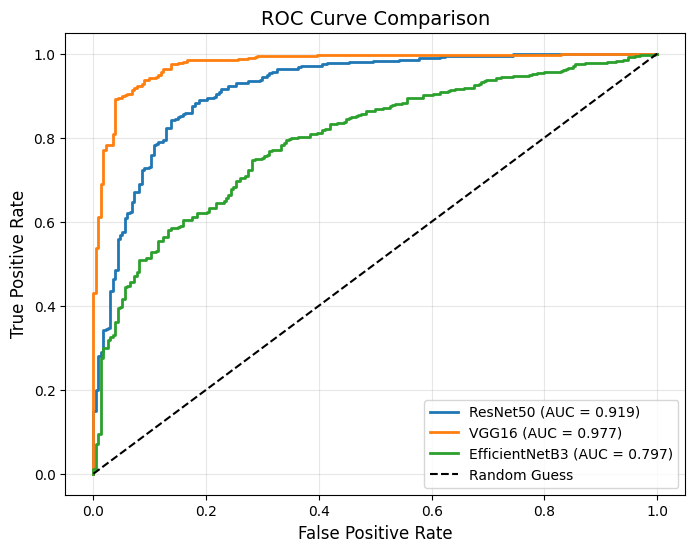

In [7]:
plt.figure(figsize=(8,6))

for name in results:
    plt.plot(
        results[name]["fpr"],
        results[name]["tpr"],
        linewidth=2,
        label=f"{name} (AUC = {results[name]['auc']:.3f})"
    )

# Random classifier line
plt.plot([0,1],[0,1],'k--', label="Random Guess")

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison", fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


In [8]:
summary = []

for name in results:
    summary.append({
        "Model": name,
        "Accuracy": results[name]["accuracy"],
        "Class Acc (Normal)": results[name]["class_accuracy"][0],
        "Class Acc (Pneumonia)": results[name]["class_accuracy"][1],
        "Precision": results[name]["precision"],
        "Recall": results[name]["recall"],
        "F1-score": results[name]["f1"],
        "AUC": results[name]["auc"],
        "Train Time (s)": train_times[name],
        "Test Time (s)": results[name]["test_time"]
    })

df_summary = pd.DataFrame(summary)
print(df_summary)

            Model  Accuracy  Class Acc (Normal)  Class Acc (Pneumonia)  \
0        ResNet50  0.858974            0.811966               0.887179   
1           VGG16  0.929487            0.850427               0.976923   
2  EfficientNetB3  0.733974            0.688034               0.761538   

   Precision    Recall  F1-score       AUC  Train Time (s)  Test Time (s)  
0   0.887179  0.887179  0.887179  0.918935     1094.358372      19.598485  
1   0.915865  0.976923  0.945409  0.976803      944.374043      21.442262  
2   0.802703  0.761538  0.781579  0.796800     1270.427692      25.749462  


In [9]:
predictions = {}

for name, model in models_dict.items():
    preds = model.predict(test_data).flatten()
    predictions[name] = preds

# Example: ResNet vs VGG
t_stat, p_value = ttest_rel(predictions["ResNet50"], predictions["VGG16"])

print("T-test ResNet vs VGG:")
print("t-stat:", t_stat)
print("p-value:", p_value)

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 250ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 255ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step
T-test ResNet vs VGG:
t-stat: -5.567233147536912
p-value: 3.849969162987465e-08


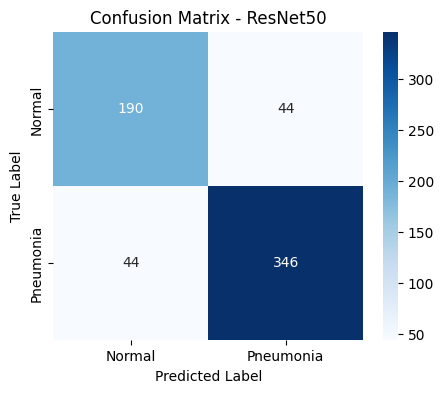

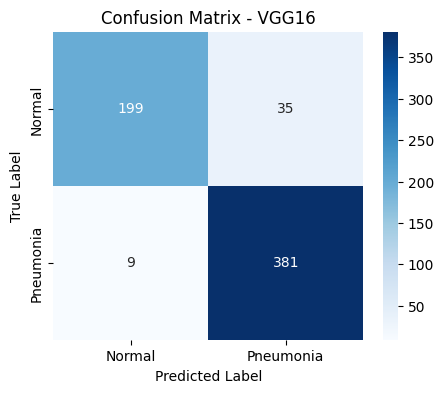

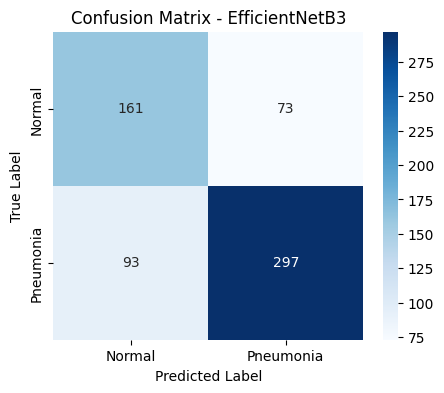

In [10]:
def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Normal", "Pneumonia"],
                yticklabels=["Normal", "Pneumonia"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Plot for all models
for name in results:
    plot_confusion_matrix(results[name]["confusion_matrix"], name)